In [4]:
from pathlib import Path
import pyscimis
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Garamond', 'Adobe Garamond Pro', 'EB Garamond', 'Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# Do you want to save the output to a CSV file? If yes:
save_output = True  # If no, change to False
# Fold location to save the final dataframe
output_path = r"C:\GitHub\pyscimis\output\ETo_Comparison.csv"

# Define the folder where the CIMIS data is stored
CIMIS_DATA_DIR = r"D:\1_Postdoc\0_Data\4_CIMIS_Spatial\Download"
# Define the folder where your 30-m ETo data is stored
# Detailed inforamtion about this dataset can ask Rui for more details
# Rui's Emails: Rui.Ray.Gao@Gmail.com or RuiGao@UCMerced.edu
MY_NC_DATA_DIR = r"E:\6_ETo_30m"
# Define the start and end dates
start_date = "2021-01-01"
end_date = "2021-12-31"
# Define the latitude and longitude for the point of interest
[latitude, longitude] = [37.354999, -120.414366]

In [ ]:
# Initial the extraction engine
extractor = pyscimis.LocalSpatialCimis(data_root_dir=CIMIS_DATA_DIR)
print("Extracting ETo values from 2-km CIMIS ETo Maps...")
df_cimis = extractor.extract_time_series(latitude=latitude, longitude=longitude, start_date=start_date, end_date=end_date, variable="ETo")
print("Extracting ETo values from the 30-m ETo maps...")
df_my_30m = extractor.extract_from_nc_dataset(nc_dir_path=MY_NC_DATA_DIR, latitude=latitude, longitude=longitude, start_date=start_date, end_date=end_date, var_name="eto")
# Put the two data frames together for comparison
df_combined = df_cimis.join(df_my_30m, how="inner")

Extracting ETo values from 2-km CIMIS ETo Maps...
Extracting ETo values from the 30-m ETo maps...


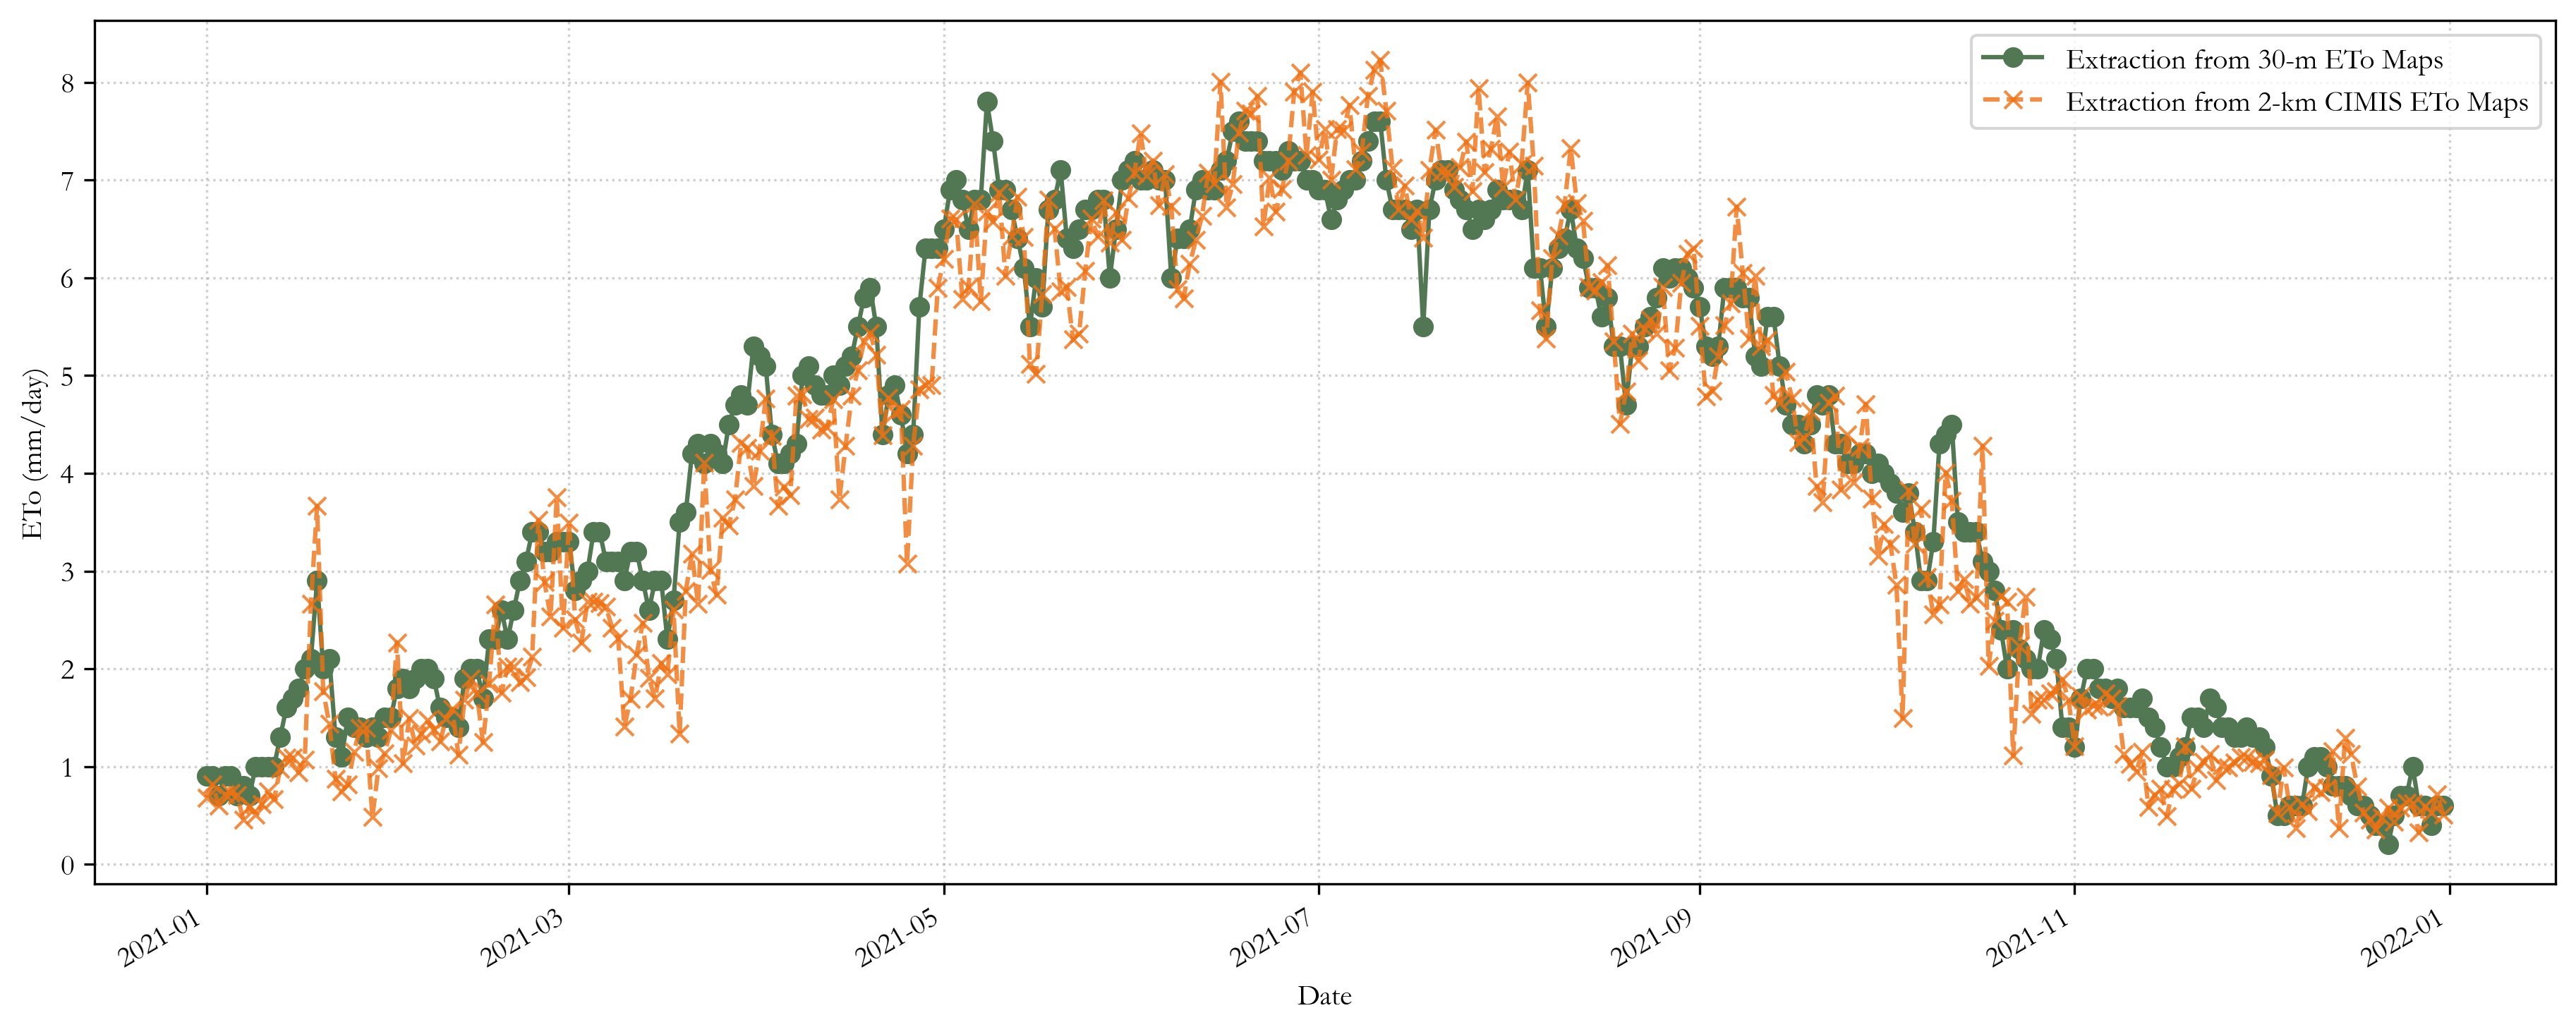

Showing the data frame head:
                 ETo  ETo_30m
Date                         
2021-01-01  0.682910      0.9
2021-01-02  0.815367      0.9
2021-01-03  0.603326      0.7
2021-01-04  0.715138      0.9
2021-01-05  0.730795      0.9
Success! Final comparison dataset safely saved to:
   C:\GitHub\pyscimis\output\ETo_Comparison.csv


True

In [6]:
plt.figure(figsize=(15, 6), dpi=300)
plt.plot(df_combined.index, df_combined["ETo_30m"], color="#527853", linestyle="-", marker="o", linewidth=1.5, label="Extraction from 30-m ETo Maps")
plt.plot(df_combined.index, df_combined["ETo"], color="#EE7214", linestyle="--", marker="x", alpha=0.8, label="Extraction from 2-km CIMIS ETo Maps")

plt.xlabel("Date")
plt.ylabel("ETo (mm/day)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.gcf().autofmt_xdate()
plt.show()

print("Showing the data frame head:")
print(df_combined.head())

extractor.save_results(df_combined, output_path=output_path, save_output=save_output)